In [3]:
from pathlib import Path
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA_DIR = Path("data/")
CI_Z = 1.96
P2_FIXED_COST_SE_SCALE = np.sqrt(16_000 / 13_000)

In [21]:
plt.rcParams.update(
    {
        "font.size": 14,
        "axes.labelsize": 14,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "axes.linewidth": 0.8,
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman"],
        "mathtext.fontset": "cm",
        "text.latex.preamble": r"\usepackage{amsmath,amssymb}",
    }
)

In [22]:
FILE_RE = re.compile(r"p(?P<p>[12])_nx(?P<nx>\d+)_.*\.out$")

def parse(path, observable="indicator_half"):
    match = FILE_RE.fullmatch(path.name)
    if not match:
        raise ValueError(f"Unexpected filename: {path.name}")
    p, nx = int(match["p"]), int(match["nx"])
    selected = False
    values = {}
    for line in path.read_text(errors="replace").splitlines():
        line = line.strip()
        found = re.fullmatch(r"Observable \d+/\d+: (.+)", line)
        if found:
            selected = found.group(1) == observable
        elif selected and " : " in line:
            key, value = (part.strip() for part in line.split(" : ", 1))
            if key == "signed difference (DK-particle)":
                values["signed"] = float(value)
            elif key == "standard error of DK estimate":
                values["se"] = float(value)
    if values.keys() != {"signed", "se"}:
        raise ValueError(f"Missing {observable} results in {path.name}")
    return {"p": p, "nx": nx, "h": 2 * np.pi / nx, "dofs": (p + 1) * nx, "error": abs(values["signed"]), **values}

def absolute_ci(signed, se):
    left, right = signed - CI_Z * se, signed + CI_Z * se
    low = np.where(left * right <= 0, 0.0, np.minimum(abs(left), abs(right)))
    return low, np.maximum(abs(left), abs(right))

files = sorted(DATA_DIR.glob("p*_nx*.out"))
if not files:
    raise FileNotFoundError(f"No output files in {DATA_DIR.resolve()}")
data = pd.DataFrame(parse(path) for path in files)
if data.duplicated(["p", "nx"]).any():
    raise ValueError("Duplicate p/nx results")
data.sort_values(["p", "h"])

,p,nx,h,dofs,error,signed,se
6,1,32,0.196350,64,0.011850,-0.011850,0.000121
5,1,28,0.224399,56,0.012956,-0.012956,0.000119
4,1,24,0.261799,48,0.014747,-0.014747,0.000115
3,1,20,0.314159,40,0.016857,-0.016857,0.000111
2,1,16,0.392699,32,0.019844,-0.019844,0.000105
1,1,12,0.523599,24,0.023993,-0.023993,0.000097
0,1,10,0.628319,20,0.021743,-0.021743,0.000102
8,1,8,0.785398,16,0.030141,-0.030141,0.000085
7,1,6,1.047198,12,0.030336,-0.030336,0.000084
15,2,32,0.196350,96,0.003500,-0.003500,0.000138


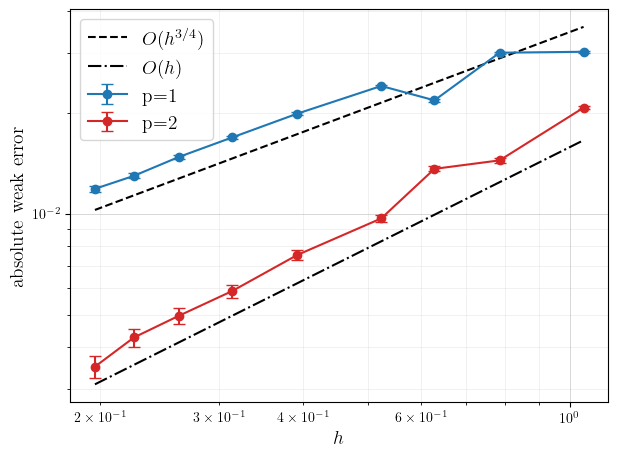

In [27]:
colors = {
    "1": "tab:blue",
    "2": "tab:red",
}
ref_coeffs = {
    "1": 1.2,
    "2": 0.8,
}

fig, ax = plt.subplots()
for p, group in data.groupby("p"):
    group = group.sort_values("h")
    low, high = absolute_ci(group.signed, group.se)
    color = colors[str(p)]
    ax.errorbar(group.h, group.error, yerr=[group.error - low, high - group.error], marker="o", capsize=4, color=color, label=f"p={p}")
    coarse = group.h.idxmax()
    if p == 1:
        reference = ref_coeffs[str(p)] * group.loc[coarse, "error"] * group.h**(0.75) / group.loc[coarse, "h"]
        ax.plot(group.h, reference, "--", color="black", label=r"$O(h^{3/4})$")
    if p==2:
        reference = ref_coeffs[str(p)] * group.loc[coarse, "error"] * group.h / group.loc[coarse, "h"]
        ax.plot(group.h, reference, "-.", color="black", label=rf"$O(h)$")
    
ax.set(xscale="log", yscale="log", xlabel=r"$h$", ylabel="absolute weak error")
ax.legend()

ax.grid(True, which="major", alpha=0.5, linewidth=0.7)
ax.grid(True, which="minor", alpha=0.3, linewidth=0.4)

fig.tight_layout()
plt.savefig("weak_error_indicator.pdf", dpi=300)
plt.show()

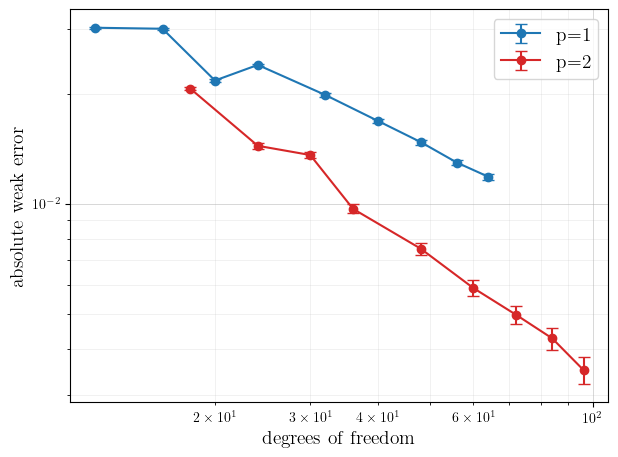

In [29]:
colors = {
    "1": "tab:blue",
    "2": "tab:red",
}

fig, ax = plt.subplots()
for p, group in data.groupby("p"):
    group = group.sort_values("dofs")
    se = group.se * (1 if p == 1 else P2_FIXED_COST_SE_SCALE)
    low, high = absolute_ci(group.signed, se)
    ax.errorbar(group.dofs, group.error, yerr=[group.error - low, high - group.error], marker="o", capsize=4, label=f"p={p}", color=colors[str(p)])
ax.set(xscale="log", yscale="log", xlabel="degrees of freedom", ylabel="absolute weak error")
ax.legend()

ax.grid(True, which="major", alpha=0.5, linewidth=0.7)
ax.grid(True, which="minor", alpha=0.3, linewidth=0.4)

fig.tight_layout()
plt.savefig("dofs_indicator.pdf", dpi=300)
plt.show()